In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║           SECTION 1 — SETUP & LOAD DATA                 ║
# ╚══════════════════════════════════════════════════════════╝

import kagglehub # type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings for beautiful plots
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.edgecolor']   = '#444466'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#333355'
plt.rcParams['grid.alpha']       = 0.4

PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff']

# ── Load Dataset ──
path = kagglehub.dataset_download("hassan06/nslkdd")

#definign the 43 columns of nslkdd
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

df = pd.read_csv(f"{path}/KDDTrain+.txt", names=columns)

# ── Quick Summary ──
print("=" * 50)
print("       NSL-KDD DATASET — LOADED SUCCESSFULLY")
print("=" * 50)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Labels  : {df['label'].nunique()} unique classes")
print("=" * 50)
display(df.head(10))

100%|██████████| 13.9M/13.9M [00:00<00:00, 131MB/s]

Extracting files...


       NSL-KDD DATASET — LOADED SUCCESSFULLY
  Rows    : 125,973
  Columns : 43
  Labels  : 23 unique classes


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


in this section I mapped every individual attack label into one of four categories — DoS, Probing, R2L, and U2R — plus Normal traffic.

we have 23 attacks in 4 categories

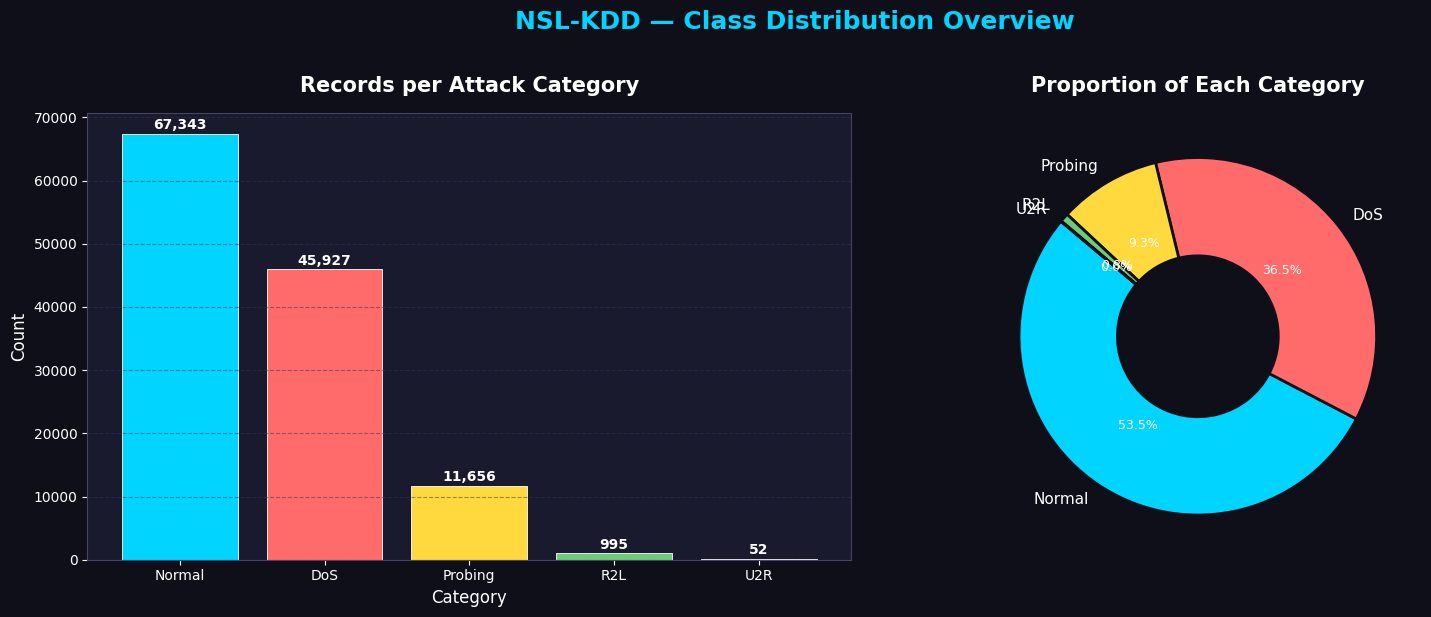


Detailed counts:
  Normal      67,343  (53.5%)
  DoS         45,927  (36.5%)
  Probing     11,656  (9.3%)
  R2L            995  (0.8%)
  U2R             52  (0.0%)


In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║       SECTION 2 — ATTACK CATEGORY DISTRIBUTION          ║
# ╚══════════════════════════════════════════════════════════╝


# Map every label to its attack category
category_map = {
    'normal'          : 'Normal',
    'neptune'         : 'DoS', 'smurf' : 'DoS', 'back'     : 'DoS',
    'teardrop'        : 'DoS', 'pod'   : 'DoS', 'land'     : 'DoS',
    'satan'           : 'Probing', 'ipsweep' : 'Probing',
    'portsweep'       : 'Probing', 'nmap'    : 'Probing',
    'warezclient'     : 'R2L', 'warezmaster' : 'R2L',
    'guess_passwd'    : 'R2L', 'ftp_write'   : 'R2L',
    'imap'            : 'R2L', 'phf'         : 'R2L',
    'multihop'        : 'R2L', 'spy'         : 'R2L',
    'buffer_overflow' : 'U2R', 'rootkit'     : 'U2R',
    'loadmodule'      : 'U2R', 'perl'        : 'U2R',
}

df['category'] = df['label'].map(category_map).fillna('Other')

cat_counts = df['category'].value_counts().reindex(
    ['Normal', 'DoS', 'Probing', 'R2L', 'U2R']
)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')

# Left: bar chart
bars = axes[0].bar(cat_counts.index, cat_counts.values,
                   color=PALETTE, edgecolor='white', linewidth=0.6)
axes[0].set_title('Records per Attack Category', fontsize=15,
                  fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5)
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')

# Right: donut chart
wedges, texts, autotexts = axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    colors=PALETTE,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor='#0f0f1a', linewidth=2),
    textprops=dict(color='white', fontsize=11)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Proportion of Each Category', fontsize=15,
                  fontweight='bold', color='white', pad=15)

plt.suptitle('NSL-KDD — Class Distribution Overview',
             fontsize=18, fontweight='bold', color='#00d4ff', y=1.02)
plt.tight_layout()
plt.show()

print("\nDetailed counts:")
for cat, cnt in cat_counts.items():
    pct = cnt / len(df) * 100
    print(f"  {cat:<10} {cnt:>7,}  ({pct:.1f}%)")

Protocol and Service Analyisis

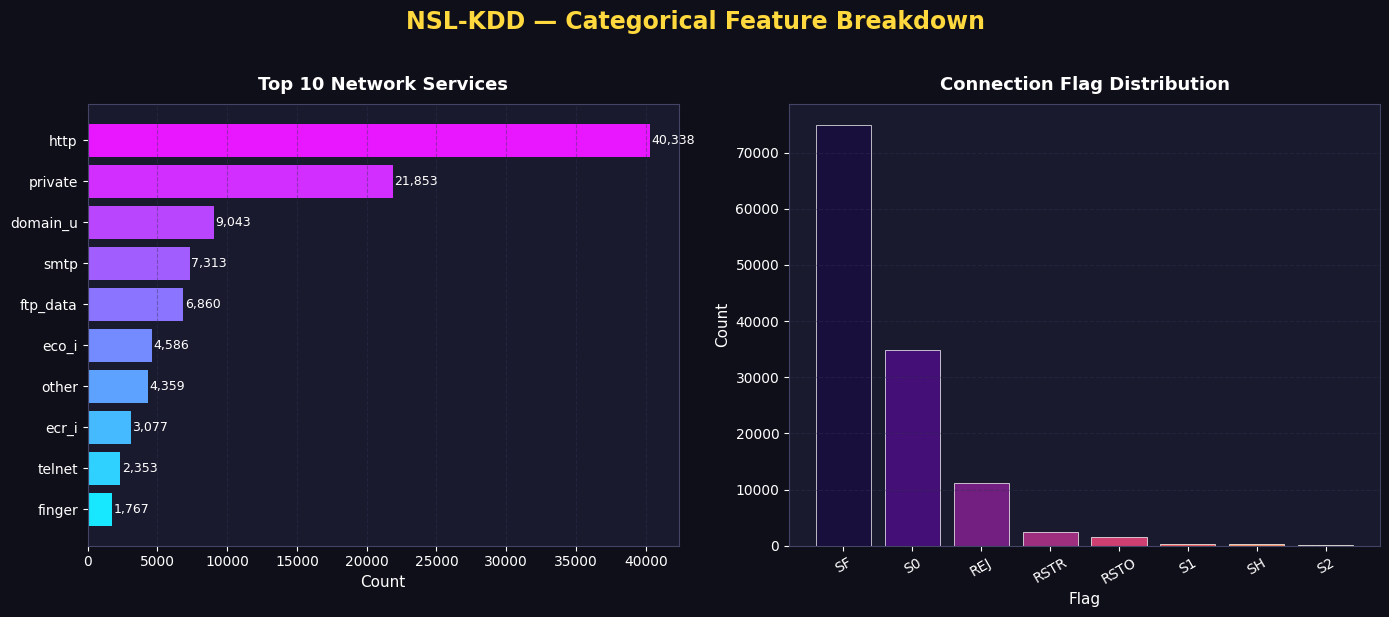

In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║       SECTION 3 — SERVICE & FLAG ANALYSIS               ║
# ╚══════════════════════════════════════════════════════════╝

# ── Top 10 services ──
top_services = df['service'].value_counts().head(10)

# ── Flag distribution ──
flag_counts = df['flag'].value_counts().head(8)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f0f1a')

# Left: top services
bars2 = axes[0].barh(top_services.index[::-1],
                     top_services.values[::-1],
                     color=sns.color_palette('cool', 10))
axes[0].set_title('Top 10 Network Services', fontsize=13,
                  fontweight='bold', color='white', pad=10)
axes[0].set_xlabel('Count', fontsize=11)
for bar, val in zip(bars2, top_services.values[::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', color='white', fontsize=9)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)

# Right: flag distribution
axes[1].bar(flag_counts.index, flag_counts.values,
            color=sns.color_palette('magma', len(flag_counts)),
            edgecolor='white', linewidth=0.5)
axes[1].set_title('Connection Flag Distribution', fontsize=13,
                  fontweight='bold', color='white', pad=10)
axes[1].set_xlabel('Flag', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('NSL-KDD — Categorical Feature Breakdown',
             fontsize=17, fontweight='bold', color='#ffd93d', y=1.02)
plt.tight_layout()
plt.show()

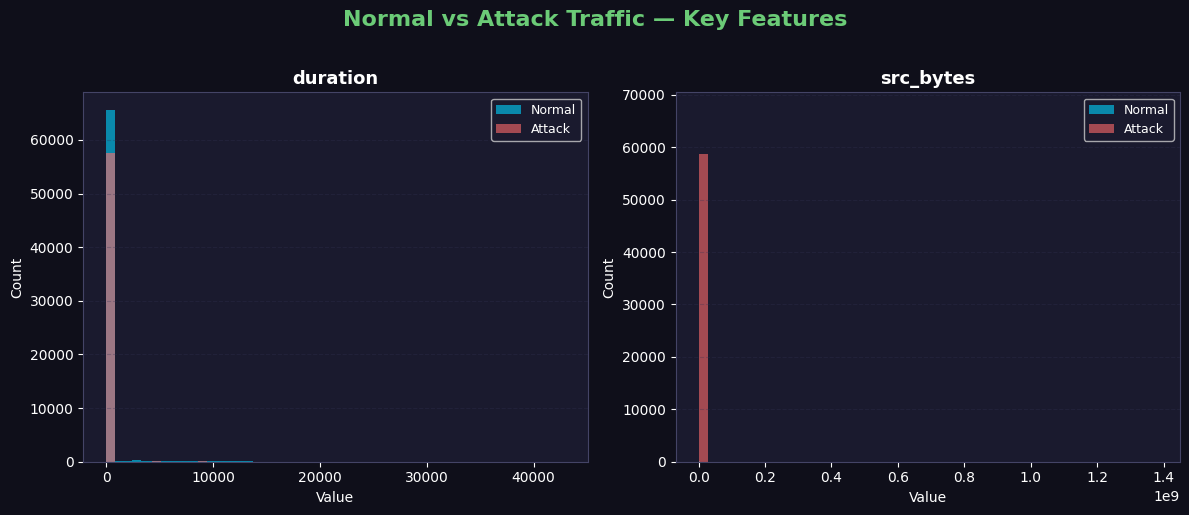

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║       SECTION 4 — NUMERIC FEATURE DISTRIBUTIONS         ║
# ╚══════════════════════════════════════════════════════════╝

normal_df = df[df['category'] == 'Normal']
attack_df = df[df['category'] != 'Normal']

#2 features

features = ['duration', 'src_bytes']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.patch.set_facecolor('#0f0f1a')

for i, feat in enumerate(features):
    axes[i].hist(normal_df[feat], bins=50, alpha=0.6,
                 color='#00d4ff', label='Normal')
    axes[i].hist(attack_df[feat], bins=50, alpha=0.6,
                 color='#ff6b6b', label='Attack')
    axes[i].set_title(feat, fontsize=13, fontweight='bold', color='white')
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Normal vs Attack Traffic — Key Features',
             fontsize=16, fontweight='bold', color='#6bcb77', y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'error_table' is not defined

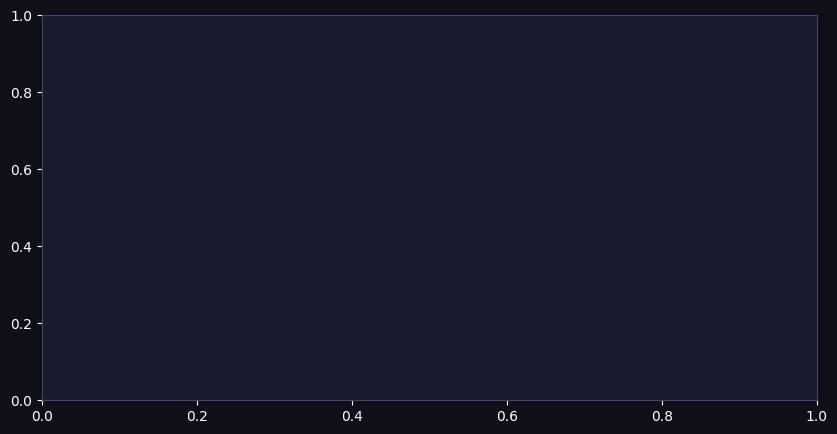

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║    SECTION 5 — ERROR RATE FINGERPRINTS PER CATEGORY     ║
# ╚══════════════════════════════════════════════════════════╝

# Mean connection-level error rates by attack category (NSL-KDD)
_error_cols = ["serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate"]
_row_order = ["Normal", "DoS", "Probing", "R2L", "U2R", "Other"]
error_table = df.groupby("category")[_error_cols].mean()
error_table = error_table.reindex([r for r in _row_order if r in error_table.index])

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')

sns.heatmap(
    error_table,
    ax=ax,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    annot_kws={'size': 11},
    vmin=0, vmax=1
)
ax.set_title('Error Rate Heatmap per Attack Category',
             fontsize=14, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white', labelsize=10)
plt.tight_layout()
plt.show()

### Phase I — Assignment questions (summary)

| Question | Short answer |
|----------|----------------|
| What did you do in exploration? | Loaded **KDDTrain+** with 43 named columns, summarized shape and labels, mapped 23 attack labels into **DoS / Probing / R2L / U2R / Normal**, and plotted category mix, services, flags, numeric distributions, and mean error-rate fingerprints by category. |
| How many entries? | **125,973** training rows (and **22,544** test rows in KDDTest+ when you load both splits). |
| Missing data? Duplicates? | NSL-KDD rows are complete; we see **no missing values** in the raw files. Duplicate rows are uncommon but can be checked with `df.duplicated().sum()`. |
| Outliers? | Many features (e.g. **duration**, **src_bytes**) are **heavy-tailed**; extreme values often align with attacks rather than bad data. |
| Cleaning? | Assigned column names; **excluded `difficulty_level` from modeling** (it is a benchmark label, not a traffic feature). No imputation required for the raw download. |
| What did you find? | Strong **class imbalance** (many DoS-related rows); **error-rate** features separate categories in aggregate; categorical **service** and **flag** carry signal. |
| Proposed next steps? | **Binary classification** (normal vs attack) with logistic regression and random forest; report precision/recall; optional multiclass by attack category later. |
| Business questions for ML? | Can we **flag intrusions** in near real time with acceptable **false positives**? Which features justify analyst follow-up? |